In [1]:
from platform import python_version
print(python_version())

3.11.14


### Calculating DEGs statistics

### For each LFC/FDR cutoff set, we get a different set of DEGs
  - LFC: LFC cutoff and FDR_LFC cutoff
  - Pathway: fdr and pval pathway cutoff and min num of genes

### Up and Down DEGs simulation
  - Up and Down DEGs/DAPs
  - Up and Down in pathways

### there are 2 statistical tables
  - pval/fdr cutoff x degs
  - pval/fdr/geneset/quantile degs_in_pathway, num_pathways

In [2]:
import os, sys, yaml
from pathlib import Path
from dotenv import load_dotenv

import numpy as np
import pandas as pd
pd.set_option('display.width', 100)
pd.set_option('max_colwidth', 80)
pd.set_option("display.precision", 3)

import seaborn as sns
sns.set_context("notebook", font_scale=1.4)

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
%matplotlib inline

sys.path.insert(1, '../src/')

ROOT0 = Path("/home/flavio/uv/perturb_agent/")
ROOT_SRC = ROOT0 / "src"

if str(ROOT_SRC) not in sys.path:
    sys.path.append(str(ROOT_SRC))

print("ROOT0:", ROOT0)
print("ROOT_SRC added:", ROOT_SRC)

from libs.Basic import *
from libs.MTD_lib import MTD
from libs.cBioPortal_lib import cBioPortal
from libs.calc_degs_lib import CALC_DEGS
# from libs.dashcyto_lib import DASH_CYTO
from libs.config_lib import Config

from IPython.display import display, HTML
# display(HTML("<style>.container { width:100% !important; }</style>"))
display(HTML("<style>:root { --jp-notebook-max-width: 100% !important; }</style>"))

with open('../params.yml', 'r') as file:
    dic_yml = yaml.safe_load(file)

# print(dic_yml)

ROOT0: /home/flavio/uv/perturb_agent
ROOT_SRC added: /home/flavio/uv/perturb_agent/src


/home/flavio/uv/perturb_agent/.venv/lib/python3.11/site-packages/Bio/__init__.py:138: BiopythonWarning: You may be importing Biopython from inside the source tree. This is bad practice and might lead to downstream issues. In particular, you might encounter ImportErrors due to missing compiled C extensions. We recommend that you try running your code from outside the source tree. If you are outside the source tree then you have a pyproject.toml file in an unexpected directory: /home/flavio/uv/perturb_agent/.venv/lib/python3.11/site-packages
  warnings.warn(
/home/flavio/uv/perturb_agent/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
email = os.getenv('email')

i_project=0

project_list = dic_yml['project_list']
n = len(project_list)
project = project_list[i_project]

s_project_list = dic_yml['s_project_list']
s_project = s_project_list[i_project]
assert n==len(project_list), f"Error project_list: there are {n} projects"

PROG_ID = 'TCGA'
PSI_ID = 'BRCA'
PSI_ID = 'ACC'
PSI_ID = 'CESC'
PSI_ID = 'PAAD'

ROOT0_DATA = ROOT0 / "data"
root_colab = ROOT0_DATA / 'colab'
root_project = ROOT0_DATA / PROG_ID

disease = PSI_ID

root_project = create_dir(ROOT0_DATA, s_project)
root_disease = create_dir(root_project, PSI_ID)

CONTEXT_DISESE = 'xxxx'
context_disease = CONTEXT_DISESE

gene_protein = dic_yml['gene_protein']
s_omics = dic_yml['s_omics']

has_age = dic_yml['has_age']
has_gender = dic_yml['has_gender']

exp_normalization = dic_yml['exp_normalization']
normalization = 'quantile_norm' if exp_normalization == True else 'not_normalized'

LFC_cut_inf = dic_yml['LFC_cut_inf']
s_pathw_enrichm_method = dic_yml['s_pathw_enrichm_method']
ptw_min_num_of_degs_cut = dic_yml['ptw_min_num_of_degs_cut']

tolerance_pPMI = dic_yml['tolerance_pPMI']
type_sat_ptw_index = dic_yml['type_sat_ptw_index']
saturation_lfc_param = dic_yml['saturation_lfc_param']

pval_pathway_cutoff = dic_yml['pval_pathway_cutoff']
fdr_pathway_cutoff = dic_yml['fdr_pathway_cutoff']
num_of_genes_cutoff = dic_yml['num_of_genes_cutoff']
enr_db_list = dic_yml['enr_db_list']


case_list = dic_yml['case_list']
dic_case_list = dic_yml['dic_case_list']

std_filename      = dic_yml['std_filename']
std_filename_list = dic_yml['std_filename_list']

min_lfc_modulation = dic_yml['min_lfc_modulation']
num_of_genes_list  = dic_yml['num_of_genes_list']
pPMI_normalized  = dic_yml['pPMI_normalized']

#--- max len for formatting purposes
s_len_case  = dic_yml['s_len_case']

n_sentences = dic_yml['n_sentences']
run_list = dic_yml['run_list']
chosen_model_list = dic_yml['chosen_model_list']
i_dfp_list = dic_yml['i_dfp_list']
chosen_model_sampling = dic_yml['chosen_model_sampling']

fdr_ptw_cutoff_list = np.arange(0.05, 0.80, 0.05)
lfc_list = np.round(np.arange(1.0, -0.01, -.025), 3)
fdr_list = np.arange(0.05, 0.76, .01)

cfg = Config(root0=ROOT0, root_disease=root_disease, disease=disease, case_list=case_list)
case = case_list[0]

n_genes_annot_ptw, n_degs, n_degs_in_ptw, n_degs_not_in_ptw, degs_in_all_ratio = -1,-1,-1,-1,-1

LFC_cut, lfc_FDR_cut, n_degs, n_degs_up, n_degs_dw = cfg.get_best_lfc_cutoff(case, 'not_normalized')

print(f"project '{project}', s_project '{s_project}'")
print(f"G/P LFC cutoffs: lfc={LFC_cut:.3f}; fdr={lfc_FDR_cut:.3f} - LFC_cut_inf={LFC_cut_inf:.3f}")
print(f"Pathway cutoffs: pval={pval_pathway_cutoff:.3f}; fdr={fdr_pathway_cutoff:.3f}; num of genes={num_of_genes_cutoff}")

Best parameter file for LFC does not exist /home/flavio/uv/perturb_agent/data/TCGA/PAAD/config/all_lfc_cutoffs_PAAD.tsv
project 'TCGA', s_project 'TCGA'
G/P LFC cutoffs: lfc=1.000; fdr=0.050 - LFC_cut_inf=0.400
Pathway cutoffs: pval=0.050; fdr=0.050; num of genes=3


In [4]:
mtd = MTD(disease=disease, gene_protein=gene_protein, s_omics=s_omics, project=project, s_project=s_project, 
          root0=ROOT0, root0_data=ROOT0_DATA, prog_id=PROG_ID, psi_id=PSI_ID,
          case_list=case_list, dic_case_list=dic_case_list, has_age=has_age, has_gender=has_gender, exp_normalization=exp_normalization,
          std_filename=std_filename, std_filename_list=std_filename_list,
          geneset_num=0, ptw_min_num_of_degs_cut=ptw_min_num_of_degs_cut,
          tolerance_pPMI=tolerance_pPMI, s_pathw_enrichm_method=s_pathw_enrichm_method,
          LFC_cut_inf=LFC_cut_inf, fdr_ptw_cutoff_list=fdr_ptw_cutoff_list,
          num_of_genes_list=num_of_genes_list, lfc_list=lfc_list, fdr_list=fdr_list, 
          min_lfc_modulation=min_lfc_modulation, type_sat_ptw_index=type_sat_ptw_index,
          saturation_lfc_param=saturation_lfc_param, enr_db_list=enr_db_list, pPMI_normalized=pPMI_normalized)

print(">>> Roots", mtd.root0, mtd.root_disease)
case = case_list[0]
print(">>>", mtd.disease, case)

mtd.cfg.set_default_best_lfc_cutoff(mtd.normalization, LFC_cut=1, lfc_FDR_cut=0.05)
ret, degs, degs_ensembl, dfdegs = mtd.open_case(case, prompt_verbose=True, verbose=False)
print("\nEcho Parameters:")
print(mtd.echo_parameters())

>>> Roots /home/flavio/uv/perturb_agent /home/flavio/uv/perturb_agent/data/TCGA/PAAD
>>> PAAD Tumor
>>> case Tumor
>>> psi_id or disease: PAAD
Error: No data available for the specified PAAD.
Error: could not find /home/flavio/uv/perturb_agent/data/TCGA/PAAD/lfc/PAAD_final_LFC_Tumor_x_CTRL_not_normalized.tsv
No dflfc table was calculated for this case Tumor

Echo Parameters:
	0/0 DEGs/ensembl.
		Up 0/0 DEGs/ensembl.
		Dw 0/0 DEGs/ensembl.

Found 0 (best=3) pathways for geneset num=0 'Reactome_Pathways_2024'
Pathway cutoffs p-value=0.050 fdr=0.050 min genes=0.05No enrichment analysis was calculated.


In [5]:
cbio = cBioPortal(root0=ROOT0, root0_data=ROOT0_DATA, memory_restriction=False)

### Get all programs

In [6]:
verbose = False

df_psi = cbio.open_primary_site(verbose=verbose)
df_psi

,prog_id,cbioportal_study_id,active,gdc_project_id,psi_id,disease_id,disease_cd,primary_site,disease_context
0,TCGA,paad_tcga_pan_can_atlas_2018,True,TCGA-PAAD,PAAD,pancreatic_adenocarcinoma,PAAD,Pancreas,"TCGA pancreatic adenocarcinoma, PanCancer Atlas"
1,CPTAC3,paad_cptac_2021,True,CPTAC-3,PAAD,pancreatic_ductal_adenocarcinoma,PAAD,Pancreas,"CPTAC publication cohort, Cell 2021; 140 pancreatic cancers"
2,TCGA,skcm_tcga_pan_can_atlas_2018,True,TCGA-SKCM,SKCM,cutaneous_melanoma,SKCM,Skin,"TCGA skin cutaneous melanoma, PanCancer Atlas"
3,TCGA,brca_tcga_pan_can_atlas_2018,True,TCGA-BRCA,BRCA,breast_invasive_carcinoma,BRCA,Breast,"TCGA breast invasive carcinoma, PanCancer Atlas"
4,CPTAC2,brca_cptac_2020,True,CPTAC-2,BRCA,breast_cancer,BRCA,Breast,"CPTAC breast cancer publication cohort, Cell 2020"


### Open primary cites from cbio

In [7]:
PROG_ID = 'TCGA'
psi_id = 'PAAD'
psi_id = 'SKCM'
psi_id = 'BRCA'

PROG_ID = 'CPTAC2'
psi_id = 'BRCA'

PROG_ID = 'CPTAC3'
psi_id = 'PAAD'


verbose=True
cbio.set_program_and_primary_site(prog_id=PROG_ID, psi_id=psi_id, verbose=verbose)


-----------------------------
>> prog_id: CPTAC3
>> psi_id: PAAD
>> primary_site: Pancreas
>> disease_id: pancreatic_ductal_adenocarcinoma
>> disease_cd: PAAD

-----------------------------
>> cbioportal_study_id: paad_cptac_2021
>> gdc_project_id: CPTAC-3

-----------------------------
>> root disease: /home/flavio/uv/perturb_agent/data/CPTAC3/PAAD
>> root samples: /home/flavio/uv/perturb_agent/data/CPTAC3/PAAD/samples
>> root lfc: /home/flavio/uv/perturb_agent/data/CPTAC3/PAAD/lfc
>> root mutations: /home/flavio/uv/perturb_agent/data/CPTAC3/PAAD/mutations
-----------------------------



,prog_id,cbioportal_study_id,active,gdc_project_id,psi_id,disease_id,disease_cd,primary_site,disease_context
1,CPTAC3,paad_cptac_2021,True,CPTAC-3,PAAD,pancreatic_ductal_adenocarcinoma,PAAD,Pancreas,"CPTAC publication cohort, Cell 2021; 140 pancreatic cancers"


### Calc expression

 - calc_file_expression_tumor_normal_gtex()
   - get_dic_expression_tumor_and_normal()
     - get_filtered_tables()
     - get_table_given_fileID()
   - prepare_normal_tumor_tables()

  
#### Tables in: root_disease / lfc

In [8]:
cbio.root_disease, cbio.root_lfc, cbio.filename_demo

(PosixPath('/home/flavio/uv/perturb_agent/data/CPTAC3/PAAD'),
 PosixPath('/home/flavio/uv/perturb_agent/data/CPTAC3/PAAD/lfc'),
 PosixPath('/home/flavio/uv/perturb_agent/data/CPTAC3/PAAD/clinical_and_demographics_for_paad_cptac_2021.tsv'))

In [9]:
cbio.root0_data

PosixPath('/home/flavio/uv/perturb_agent/data')

### Get cases, subtypes and clin_demo tables

In [10]:
verbose=False
force=False

PROG_ID = 'CPTAC2'
psi_id = 'BRCA'

PROG_ID = 'TCGA'
psi_id = 'SKCM'
psi_id = 'BRCA'
psi_id = 'PAAD'

PROG_ID = 'CPTAC3'
psi_id = 'PAAD'

cbio.set_program_and_primary_site(prog_id=PROG_ID, psi_id=psi_id, verbose=verbose)

df_cases, df_subt, df_clin_demo, df_case_bar = cbio.get_cases_and_subtypes(batch_size=200, force=force, verbose=verbose)

df_cases.shape, df_clin_demo.shape, df_case_bar.shape

((170, 27), (140, 20), (140, 2))

In [11]:
verbose=False

# dic_tumor, dic_normal = cbio.get_dic_expression_tumor_and_normal(verbose=verbose)

In [12]:
verbose=False
force=False

imax_tumor=200
imax_normal=100

df_tumor, df_normal, df_gtex_ctrl = cbio.calc_file_expression_tumor_normal_gtex(
            imax_tumor=imax_tumor, imax_normal=imax_normal, force=force, verbose=verbose)

print(df_tumor.shape[1], df_normal.shape[1], df_gtex_ctrl.shape[1])

52 23 0


In [13]:
df_tumor.head(3)

,geneid,symbol,biotype,T-C3L-02890,T-C3L-03635,T-C3L-02701,T-C3L-04072,T-C3L-00589,T-C3L-03123,T-C3N-01383,...,T-C3L-03632,T-C3N-02589,T-C3N-03006,T-C3N-02996,T-C3N-03754,T-C3L-03639,T-C3L-02606,T-C3N-03665,T-C3N-03173,T-C3N-02696
0,ENSG00000000003,TSPAN6,protein_coding,1486,2083,1558,546,1208,648,896,...,730,1539,1671,1150,1709,2294,1693,368,1224,1882
1,ENSG00000000005,TNMD,protein_coding,12,97,15,1,14,2,5,...,50,7,11,12,14,31,5,4,8,9
2,ENSG00000000419,DPM1,protein_coding,1330,1521,1499,986,1388,974,649,...,949,1635,1768,913,1183,1592,1175,459,1364,1464


In [14]:
df_normal.head(3)

,geneid,symbol,biotype,N-C3L-04072,N-C3L-00589,N-C3L-03123,N-C3L-04080,N-C3L-00640,N-C3N-01719,N-C3L-07033,...,N-C3N-01899,N-C3N-00517,N-C3N-03069,N-C3N-02765,N-C3L-07037,N-C3N-02589,N-C3N-02996,N-C3L-02606,N-C3N-03173,N-C3N-02696
0,ENSG00000000003,TSPAN6,protein_coding,1633,1302,1079,1367,896,1188,1275,...,791,1695,891,1063,1261,1821,554,1244,977,1576
1,ENSG00000000005,TNMD,protein_coding,0,8,9,3,4,7,0,...,1,2,0,7,2,6,1,1,3,39
2,ENSG00000000419,DPM1,protein_coding,1281,937,655,956,1000,1504,1087,...,619,1075,703,601,1059,1289,342,773,676,783


In [15]:
df_gtex_ctrl.head(3)

""


### Data treatment

1. get raw dfc
2. filter low-expression genes
3. normalize for library size
4. variance-stabilizing transformation
5. select most variable genes
6. cluster samples into k = 3..8 groups
7. evaluate clusters
8. find gene signatures for each cluster

A low-expression gene can be biologically important and even differentially expressed, especially if it is a transcription factor, cytokine, receptor, lncRNA, or rare-cell marker.

But for unsupervised tumor clustering, we usually do not want thousands of genes with mostly zero/very low counts because they add noise and unstable distances.

In [16]:
verbose=False
force=False

imax_tumor=250
imax_normal=50

exclude_prog_list=['CCLE']
disease_cd = 'PAAD'

dfn_tumor, dfn_normal, df_gtex, df_summ = cbio.get_all_data_from_disease(disease_cd=disease_cd, 
                                                           imax_tumor=imax_tumor, imax_normal=imax_normal,
                                                           exclude_prog_list=exclude_prog_list,
                                                           force=force, verbose=verbose)
print("\n")
print(">> dfn_tumor", dfn_tumor.shape)
print(">> dfn_normal", dfn_normal.shape)

Error reading csv/tsv '/home/flavio/uv/perturb_agent/data/multi_progs/PAAD/lfc/expression_gtex_controls_counts.tsv': No columns to parse from file


>> dfn_tumor (60616, 134)
>> dfn_normal (60616, 25)


In [17]:
dfn_tumor.head(3)

,geneid,symbol,biotype,T-C3L-02890,T-C3L-03635,T-C3L-02701,T-C3L-04072,T-C3L-00589,T-C3L-03123,T-C3N-01383,...,T-TCGA-HZ-7289,T-TCGA-3A-A9IN,T-TCGA-3A-A9IS,T-TCGA-2L-AAQM,T-TCGA-3A-A9IR,T-TCGA-3A-A9IV,T-TCGA-3A-A9IO,T-TCGA-2J-AABT,T-TCGA-H6-A45N,T-TCGA-3A-A9IJ
0,ENSG00000000003,TSPAN6,protein_coding,1486,2083,1558,546,1208,648,896,...,2506,442,38,299,77,158,394,659,1294,395
1,ENSG00000000005,TNMD,protein_coding,12,97,15,1,14,2,5,...,2,172,4,2,1,2,14,3,3,0
2,ENSG00000000419,DPM1,protein_coding,1330,1521,1499,986,1388,974,649,...,1638,940,1372,1008,1493,1059,922,839,717,1034


In [18]:
dfn_normal.head(3)

,geneid,symbol,biotype,N-C3L-04072,N-C3L-00589,N-C3L-03123,N-C3L-04080,N-C3L-00640,N-C3N-01719,N-C3L-07033,...,N-C3N-03069,N-C3N-02765,N-C3L-07037,N-C3N-02589,N-C3N-02996,N-C3L-02606,N-C3N-03173,N-C3N-02696,N-TCGA-H6-8124,N-TCGA-H6-A45N
0,ENSG00000000003,TSPAN6,protein_coding,1633,1302,1079,1367,896,1188,1275,...,891,1063,1261,1821,554,1244,977,1576,3738,369
1,ENSG00000000005,TNMD,protein_coding,0,8,9,3,4,7,0,...,0,7,2,6,1,1,3,39,4,5
2,ENSG00000000419,DPM1,protein_coding,1281,937,655,956,1000,1504,1087,...,703,601,1059,1289,342,773,676,783,1532,1023


In [19]:
cbio.df_metadata

,condition,program,dataset,condition_numeric
cols,,,,
T-C3L-02890,tumor,CPTAC3,PAAD,1.0
T-C3L-03635,tumor,CPTAC3,PAAD,1.0
T-C3L-02701,tumor,CPTAC3,PAAD,1.0
T-C3L-04072,tumor,CPTAC3,PAAD,1.0
T-C3L-00589,tumor,CPTAC3,PAAD,1.0
...,...,...,...,...
N-C3L-02606,normal,CPTAC3,PAAD,0.0
N-C3N-03173,normal,CPTAC3,PAAD,0.0
N-C3N-02696,normal,CPTAC3,PAAD,0.0


In [20]:
print(pd.crosstab(cbio.df_metadata["program"], cbio.df_metadata["condition"]))

condition  normal  tumor
program                 
CPTAC3         20     49
TCGA            2     82


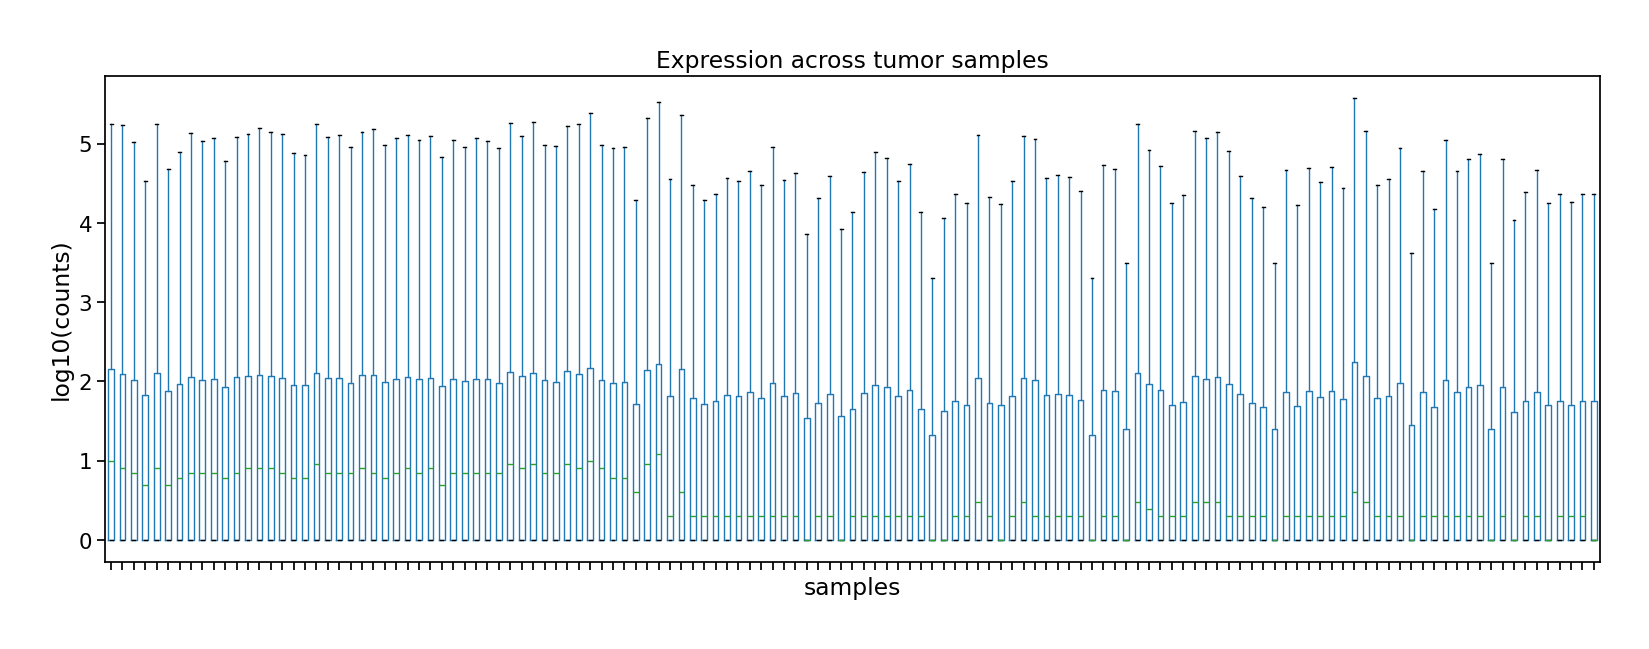

In [25]:
cbio.plot_boxplot_expression(dfn_tumor, do_log10=True, title = "Expression across tumor samples")

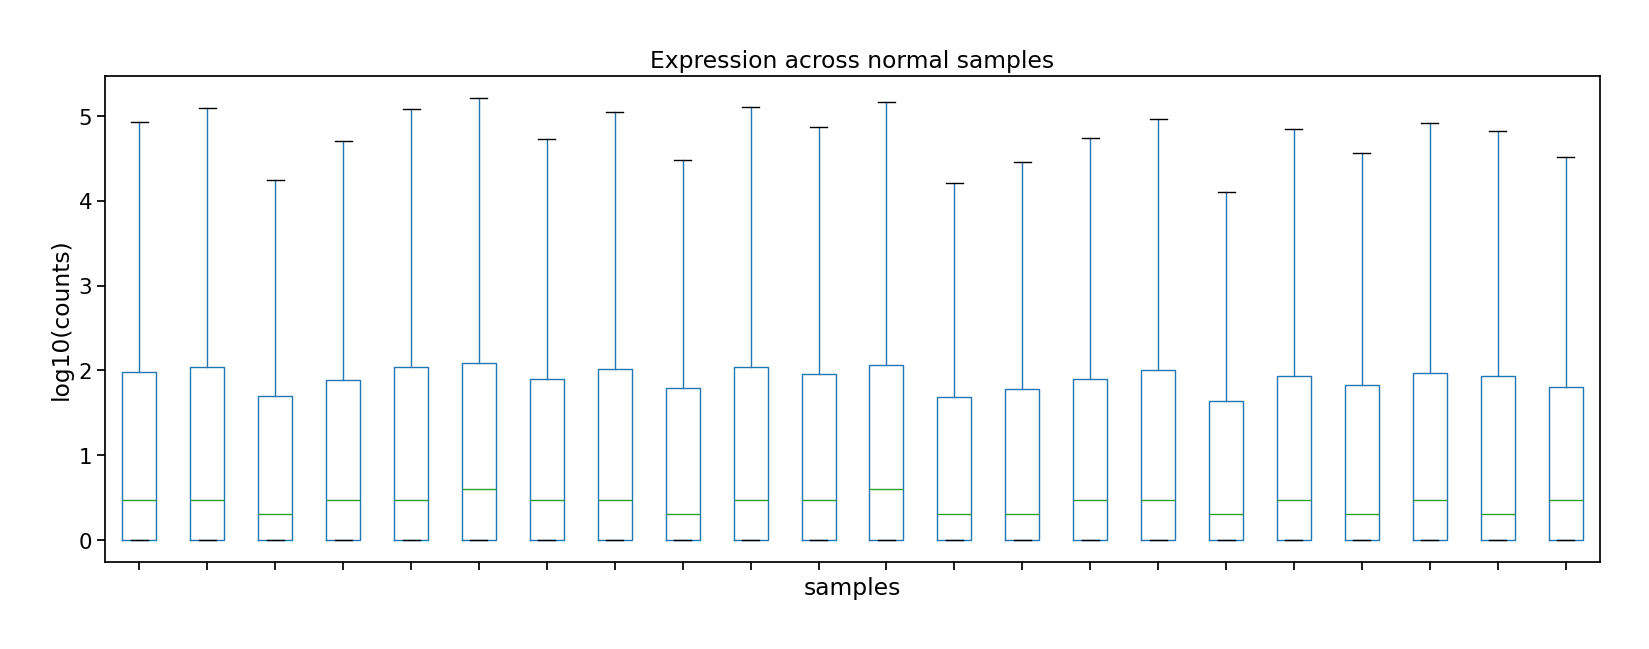

In [24]:
cbio.plot_boxplot_expression(dfn_normal, do_log10=True, title = "Expression across normal samples")

### Validate expression data merge

In [26]:
from scipy import stats


def box_stats(v, pseudo=1):
    """Q1/Q2/Q3 + whiskers (matplotlib convention) on log10(counts+pseudo)."""
    L  = np.log10(v + pseudo)
    D  = np.log10(v[v > 0])                      # detected genes only

    q1, q2, q3 = np.percentile(L, [25, 50, 75])
    iqr = q3 - q1
    lo, hi = q1 - 1.5*iqr, q3 + 1.5*iqr
    d1, d2, d3 = np.percentile(D, [25, 50, 75]) if D.size else (np.nan,)*3

    return pd.Series({
        'q1': q1, 'q2': q2, 'q3': q3, 'iqr': iqr,
        'whisker_lo': L[L >= lo].min(),
        'whisker_hi': L[L <= hi].max(),
        'n_out_hi'  : int((L > hi).sum()),
        'q1_det': d1, 'q2_det': d2, 'q3_det': d3,
        'frac_zero' : float((v == 0).mean()),
        'n_detected': int((v > 0).sum()),
        'log10_lib' : np.log10(v.sum()),
    })



In [ ]:
# counts matrix, tumors only
X = (dfn_tumor.drop(columns=cbio.ANNOT_COLS)
     .apply(pd.to_numeric, errors='coerce').fillna(0))

df_meta = cbio.df_metadata.loc[X.columns]


st = X.apply(lambda c: box_stats(c.to_numpy(float))).T.join(df_meta[['program']])

print(st.groupby('program').median().round(3).T)




program        CPTAC3       TCGA
q1              0.000      0.000
q2              0.845      0.301
q3              2.033      1.820
iqr             2.033      1.820
whisker_lo      0.000      0.000
whisker_hi      5.070      4.546
n_out_hi       13.000    130.500
q1_det          0.699      0.602
q2_det          1.477      1.623
q3_det          2.634      2.951
frac_zero       0.309      0.459
n_detected  41887.000  32815.000
log10_lib       7.588      7.685


In [34]:
# cohort test
st = X.apply(lambda c: box_stats(c.to_numpy(float))).T.join(df_meta[['dataset']])

rows = []
for m in st.columns.drop('dataset'):
    a = st.loc[st.dataset == 'CPTAC3', m].astype(float)
    b = st.loc[st.dataset == 'TCGA',   m].astype(float)
    u, p = stats.mannwhitneyu(a, b)
    rows.append({'metric': m, 'CPTAC3': a.median(), 'TCGA': b.median(),
                 'delta': b.median() - a.median(),
                 'cliffs': 2*u/(a.size*b.size) - 1, 'p': p})
cmp = pd.DataFrame(rows).set_index('metric')
cmp['fdr'] = stats.false_discovery_control(cmp.p.values)
print(cmp.round(4))

ValueError: `ps` must include only numbers between 0 and 1.

In [28]:
df_meta

,condition,program,dataset,condition_numeric
T-C3L-02890,tumor,CPTAC3,PAAD,1.0
T-C3L-03635,tumor,CPTAC3,PAAD,1.0
T-C3L-02701,tumor,CPTAC3,PAAD,1.0
T-C3L-04072,tumor,CPTAC3,PAAD,1.0
T-C3L-00589,tumor,CPTAC3,PAAD,1.0
...,...,...,...,...
T-TCGA-3A-A9IV,tumor,TCGA,PAAD,1.0
T-TCGA-3A-A9IO,tumor,TCGA,PAAD,1.0
T-TCGA-2J-AABT,tumor,TCGA,PAAD,1.0
T-TCGA-H6-A45N,tumor,TCGA,PAAD,1.0


### Development & tests

In [ ]:
def plot_boxplot_expression(df: pd.DataFrame, 
                            title: str = "Expression across samples", 
                            xlabel = "samples", ylabel = "counts",
                            do_log10:bool = False,
                            figsize=(16, 6)):

    fig, ax = plt.subplots(figsize=figsize)

    sample_cols = [c for c in df.columns if c not in cbio.ANNOT_COLS]
    df = df[sample_cols].copy()

    if do_log10:
        df = np.log10(df + 1)
        ylabel = f"log10({ylabel})"

    df.boxplot(
        ax=ax,
        grid=False,
        showfliers=False,
    )

    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.tick_params(axis="x", labelbottom=False)

    plt.tight_layout()
    plt.show()